In [1]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 113.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.4/377.4 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 12.7 MB/s eta 0:00:00


In [9]:

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import random

n_qubits = 3
shots = 1000

qrng = QuantumCircuit(n_qubits)
qrng.h(range(n_qubits))
qrng.measure_all()

backend = AerSimulator()

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qrng = pm.run(qrng)

sampler = Sampler(mode=backend)
job = sampler.run([isa_qrng], shots=shots)
result = job.result()

counts = result[0].data.meas.get_counts()
print("Distribution result (frequency):")
print(counts)

random_state = random.choice(list(counts.keys()))
random_number = int(random_state, 2)
print(f"\n🎲 Random Number Generator: {random_number}")

Distribution result (frequency):
{'000': 130, '110': 127, '011': 129, '101': 129, '100': 130, '010': 125, '111': 122, '001': 108}

🎲 Random Number Generator: 7


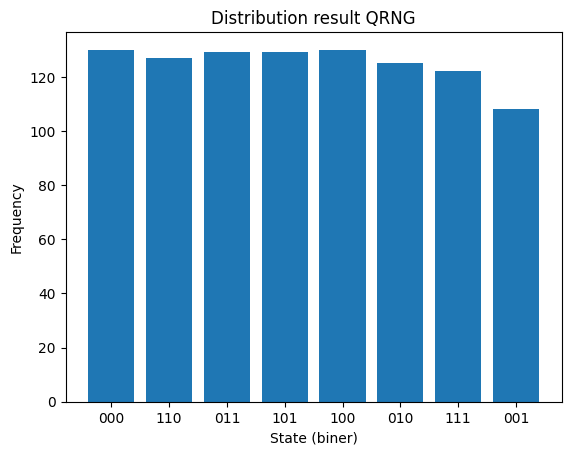

In [11]:

import matplotlib.pyplot as plt

plt.bar(counts.keys(), counts.values())
plt.xlabel("State (biner)")
plt.ylabel("Frequency")
plt.title("Distribution result QRNG")
plt.show()